In [1]:
# https://api.nepalytix.com/api/live-market/floorsheet/
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
import requests

In [11]:
import requests

url = "https://api.nepalytix.com/api/live-market/floorsheet/"
response = requests.get(url)
data = response.json()
data

{'message': 'OK',
 'latest_date': '2026-06-04',
 'scan_time': '2026-06-04 12:47:00.166434',
 'filters': {'symbol': None},
 'summary': {'total_transactions': 18845,
  'total_quantity': 3513381,
  'total_amount': 1423789558.38,
  'avg_deal_size': 75552.64305545237},
 'largest_transaction': {'symbol': 'BUNGAL',
  'buyer': '-',
  'seller': '-',
  'quantity': 33011,
  'rate': 736.0,
  'amount': 24296096.0,
  'transaction_time': '2026-06-04 10:46:00.309199'},
 'top_5_by_amount': [{'symbol': 'BUNGAL',
   'buyer': '-',
   'seller': '-',
   'quantity': 33011,
   'rate': 736.0,
   'amount': 24296096.0,
   'transaction_time': '2026-06-04 10:46:00.309199'},
  {'symbol': 'RADHI',
   'buyer': '-',
   'seller': '-',
   'quantity': 30000,
   'rate': 780.0,
   'amount': 23400000.0,
   'transaction_time': '2026-06-04 10:46:00.079780'},
  {'symbol': 'CGH',
   'buyer': '-',
   'seller': '-',
   'quantity': 15000,
   'rate': 790.0,
   'amount': 11850000.0,
   'transaction_time': '2026-06-04 12:07:19.898352

In [9]:
data["summary"]

{'total_transactions': 62148,
 'total_quantity': 13521619,
 'total_amount': 5738178165.24,
 'avg_deal_size': 92330.85803630044}

In [ ]:
# https://api.nepalytix.com/api/live-market/floorsheet/amount-over-time/?interval=minute
# https://api.nepalytix.com/api/live-market/floorsheet/

In [14]:
99419400/10000000

9.94194

In [17]:
round(data['largest_transaction']['amount']/10000000,2)

9.94

In [19]:
def extract_data():
    url = "https://api.nepalytix.com/api/live-market/floorsheet/"
    response = requests.get(url)
    data = response.json()
    summary_data=data["summary"]
    print("Kpis : ")
    print(f"total_transactions : {summary_data["total_transactions"]}")
    print(f"total Quantity : {summary_data["total_quantity"]}")
    print(f"Total Amount : {summary_data["total_amount"]}")
    print(f"Average Deal Size  : {summary_data["avg_deal_size"]}")
    print(f"Largest Transactions   : {round(data['largest_transaction']['amount']/10000000,2)}")

    print("\n\n")
    top_5_amounts=pd.DataFrame(data['top_5_by_amount'])
    top_5_amounts["amount_in_cr"]=(top_5_amounts["amount"]/10000000).apply(lambda x : round(x,2))
    total = top_5_amounts["amount_in_cr"].sum()
    top_5_amounts["percentage"] = (
        top_5_amounts["amount_in_cr"] / total * 100
    )
    
    labels = [
        f"{symbol}\nRs{amount:.2f} Cr\n{pct:.1f}%"
        for symbol, amount, pct in zip(
            top_5_amounts["symbol"],
            top_5_amounts["amount_in_cr"],
            top_5_amounts["percentage"]
        )
    ]
    
    colors = plt.cm.Set3(range(len(top_5_amounts)))
    plt.figure(figsize=(8, 4))
    squarify.plot(
        sizes=top_5_amounts["amount_in_cr"],
        label=labels,
        color=colors,
        alpha=0.8,
        text_kwargs={"fontsize": 10}
    )
    
    plt.axis("off")
    plt.title("Top 5 Amounts Treemap", fontsize=16)
    
    legend_labels = [
        f"{sym}: Rs{amt:.2f} Cr ({pct:.1f}%)"
        for sym, amt, pct in zip(
            top_5_amounts["symbol"],
            top_5_amounts["amount_in_cr"],
            top_5_amounts["percentage"]
        )
    ]
    
    plt.legend(
        legend_labels,
        title="Symbols",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )
    
    plt.tight_layout()
    plt.show()


    top_5_qt=pd.DataFrame(data["top_5_by_quantity"])
    plt.figure(figsize=(10,4))
    plt.title("top 5 stocks by quantity")
    ax=sns.barplot(top_5_qt,y="symbol",x="quantity",errorbar=None,color="green")
    for item in ax.containers:
        ax.bar_label(item)
    plt.show()


    bulk_transactions_lists=pd.DataFrame(data['bulk_transactions']["data"])
    print(bulk_transactions_lists)



In [8]:
import matplotlib.pyplot as plt

Kpis : 
total_transactions : 19403
total Quantity : 3583003
Total Amount : 1456706450.78
Average Deal Size  : 75076.35163531413
Largest Transactions   : 2.43





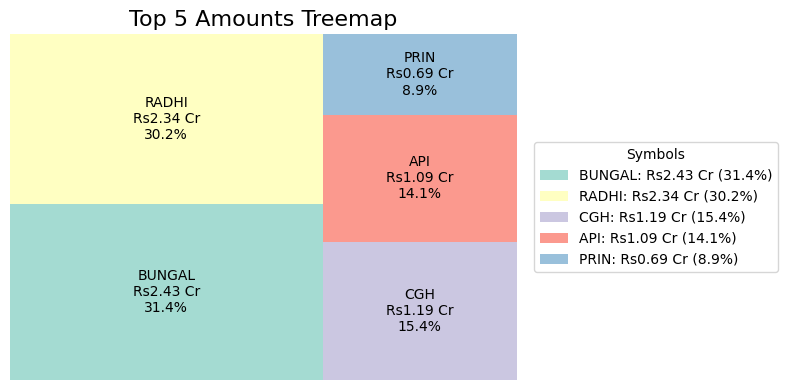

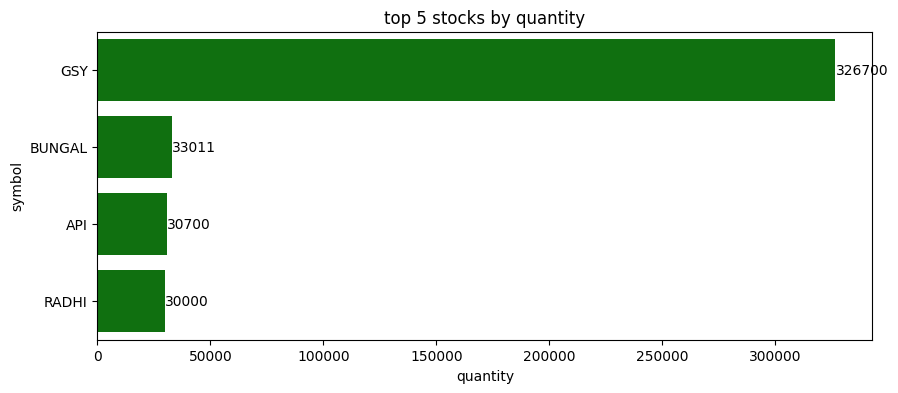

    symbol buyer seller  quantity     rate      amount  \
0   BUNGAL     -      -      2910   739.00   2150490.0   
1     RIDI     -      -      9900   363.20   3595680.0   
2      LSL     -      -     24824   224.00   5560576.0   
3     LBBL     -      -      4964   506.00   2511784.0   
4     PRIN     -      -      9700   716.00   6945200.0   
5    HDHPC     -      -     10000   223.00   2230000.0   
6     NRIC     -      -      2000  1115.00   2230000.0   
7     NRIC     -      -      1940  1110.00   2153400.0   
8      API     -      -     18700   355.00   6638500.0   
9      API     -      -     30700   355.00  10898500.0   
10     CGH     -      -     15000   790.00  11850000.0   
11    NICL     -      -      8981   565.00   5074265.0   
12    BHCL     -      -      4000   615.10   2460400.0   
13    GFCL     -      -      6500   675.00   4387500.0   
14    CFCL     -      -      4000   615.00   2460000.0   
15    TVCL     -      -      8720   510.20   4448944.0   
16  SAPDBL    

In [20]:
extract_data()

In [27]:
top_5_amounts=pd.DataFrame(data['top_5_by_amount'])
top_5_amounts["amount_in_cr"]=(top_5_amounts["amount"]/10000000).apply(lambda x : round(x,2))

In [2]:
import squarify

# # Calculate percentages
# total = top_5_amounts["amount_in_cr"].sum()
# top_5_amounts["percentage"] = (
#     top_5_amounts["amount_in_cr"] / total * 100
# )

# # Labels with amount and percentage
# labels = [
#     f"{symbol}\nRs{amount:.2f} Cr\n{pct:.1f}%"
#     for symbol, amount, pct in zip(
#         top_5_amounts["symbol"],
#         top_5_amounts["amount_in_cr"],
#         top_5_amounts["percentage"]
#     )
# ]

# # Colors
# colors = plt.cm.Set3(range(len(top_5_amounts)))

# plt.figure(figsize=(8, 4))

# # Treemap
# squarify.plot(
#     sizes=top_5_amounts["amount_in_cr"],
#     label=labels,
#     color=colors,
#     alpha=0.8,
#     text_kwargs={"fontsize": 10}
# )

# plt.axis("off")
# plt.title("Top 5 Amounts Treemap", fontsize=16)

# # Legend
# legend_labels = [
#     f"{sym}: Rs{amt:.2f} Cr ({pct:.1f}%)"
#     for sym, amt, pct in zip(
#         top_5_amounts["symbol"],
#         top_5_amounts["amount_in_cr"],
#         top_5_amounts["percentage"]
#     )
# ]

# plt.legend(
#     legend_labels,
#     title="Symbols",
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5)
# )

# plt.tight_layout()
# plt.show()

In [31]:
top_5_amounts

,symbol,buyer,seller,quantity,rate,amount,transaction_time,amount_in_cr
0,NBBD2085,101,6,91800,1083.0,99419400.0,2026-06-03 14:54:45.158086,9.94
1,SBLPO,17,16,450000,216.4,97380000.0,2026-06-03 11:11:08.761822,9.74
2,SBLD84,44,101,45870,1075.0,49310250.0,2026-06-03 14:21:12.202147,4.93
3,NMFBSP,54,33,48656,628.0,30555968.0,2026-06-03 12:55:54.634454,3.06
4,SBLD84,32,101,19140,1075.0,20575500.0,2026-06-03 14:19:46.733766,2.06


In [33]:
top_5_amounts["symbol"]

0    NBBD2085
1       SBLPO
2      SBLD84
3      NMFBSP
4      SBLD84
Name: symbol, dtype: object

In [43]:
pd.DataFrame(data['top_5_by_quantity'])

top_5_amounts=pd.DataFrame(data['top_5_by_amount'])
top_5_amounts["amount_in_cr"]=(top_5_amounts["amount"]/10000000).apply(lambda x : round(x,2))

,symbol,buyer,seller,quantity,rate,amount,transaction_time
0,SBLPO,17,16,450000,216.4,97380000.0,2026-06-03 11:11:08.761822
1,KDBY,14,49,434800,11.4,4956720.0,2026-06-03 12:32:51.574768
2,KDBY,14,49,200000,11.4,2280000.0,2026-06-03 12:32:58.438081
3,NBBD2085,101,6,91800,1083.0,99419400.0,2026-06-03 14:54:45.158086
4,HLICF,34,10,80000,9.0,720000.0,2026-06-03 11:26:57.141081


In [48]:
data.keys()

dict_keys(['message', 'latest_date', 'scan_time', 'filters', 'summary', 'largest_transaction', 'top_5_by_amount', 'top_5_by_quantity', 'transactions_over_time', 'bulk_transactions'])

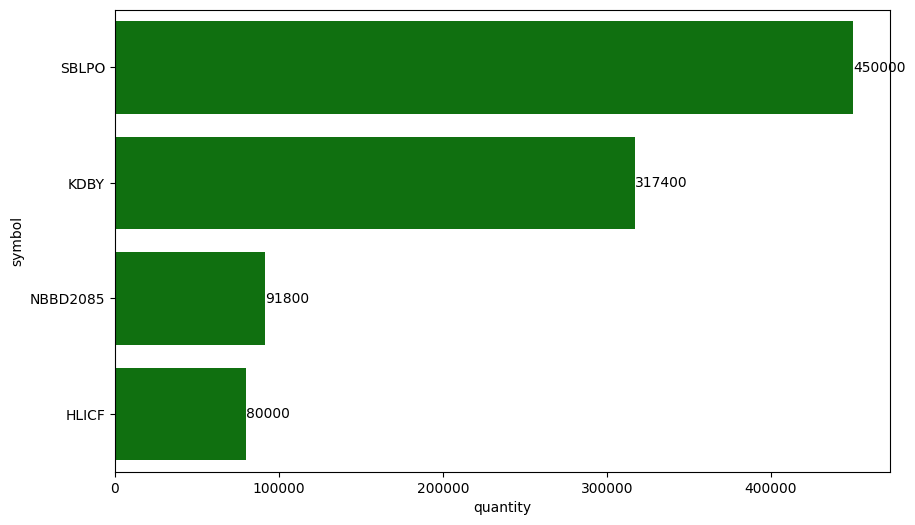

In [73]:
top_5_qt=pd.DataFrame(data["top_5_by_quantity"])
top_5_qt

plt.figure(figsize=(10,6))
ax=sns.barplot(top_5_qt,y="symbol",x="quantity",errorbar=None,color="green")
for item in ax.containers:
    ax.bar_label(item)

In [72]:
pd.DataFrame(data["top_5_by_quantity"])

,symbol,buyer,seller,quantity,rate,amount,transaction_time
0,SBLPO,17,16,450000,216.4,97380000.0,2026-06-03 11:11:08.761822
1,KDBY,14,49,434800,11.4,4956720.0,2026-06-03 12:32:51.574768
2,KDBY,14,49,200000,11.4,2280000.0,2026-06-03 12:32:58.438081
3,NBBD2085,101,6,91800,1083.0,99419400.0,2026-06-03 14:54:45.158086
4,HLICF,34,10,80000,9.0,720000.0,2026-06-03 11:26:57.141081


In [82]:
import os
os.getcwd()

'C:\\Users\\HP\\Desktop\\data_extractions\\api_datasets'

In [13]:
data.keys()

dict_keys(['message', 'latest_date', 'scan_time', 'filters', 'summary', 'largest_transaction', 'top_5_by_amount', 'top_5_by_quantity', 'transactions_over_time', 'bulk_transactions'])

In [18]:
bulk_transactions_lists=pd.DataFrame(data['bulk_transactions']["data"])
bulk_transactions_lists

,symbol,buyer,seller,quantity,rate,amount,transaction_time
0,BUNGAL,-,-,2910,739.00,2150490.0,2026-06-04 12:38:38.826071
1,RIDI,-,-,9900,363.20,3595680.0,2026-06-04 12:38:05.307129
2,LSL,-,-,24824,224.00,5560576.0,2026-06-04 12:36:39.452575
3,LBBL,-,-,4964,506.00,2511784.0,2026-06-04 12:35:24.606349
4,PRIN,-,-,9700,716.00,6945200.0,2026-06-04 12:33:19.754453
5,HDHPC,-,-,10000,223.00,2230000.0,2026-06-04 12:24:22.077678
6,NRIC,-,-,2000,1115.00,2230000.0,2026-06-04 12:18:53.128917
7,NRIC,-,-,1940,1110.00,2153400.0,2026-06-04 12:12:26.569110
8,API,-,-,18700,355.00,6638500.0,2026-06-04 12:10:47.345710
9,API,-,-,30700,355.00,10898500.0,2026-06-04 12:10:24.138857


In [21]:
data["transactions_over_time"]

[{'bucket': '2026-06-04 05:00:00.000000',
  'count': 7522,
  'quantity': 1862606,
  'amount': 621213800.31},
 {'bucket': '2026-06-04 06:00:00.000000',
  'count': 11030,
  'quantity': 1607825,
  'amount': 784141901.77},
 {'bucket': '2026-06-04 07:00:00.000000',
  'count': 293,
  'quantity': 42950,
  'amount': 18433856.3}]

### like a dashboards 

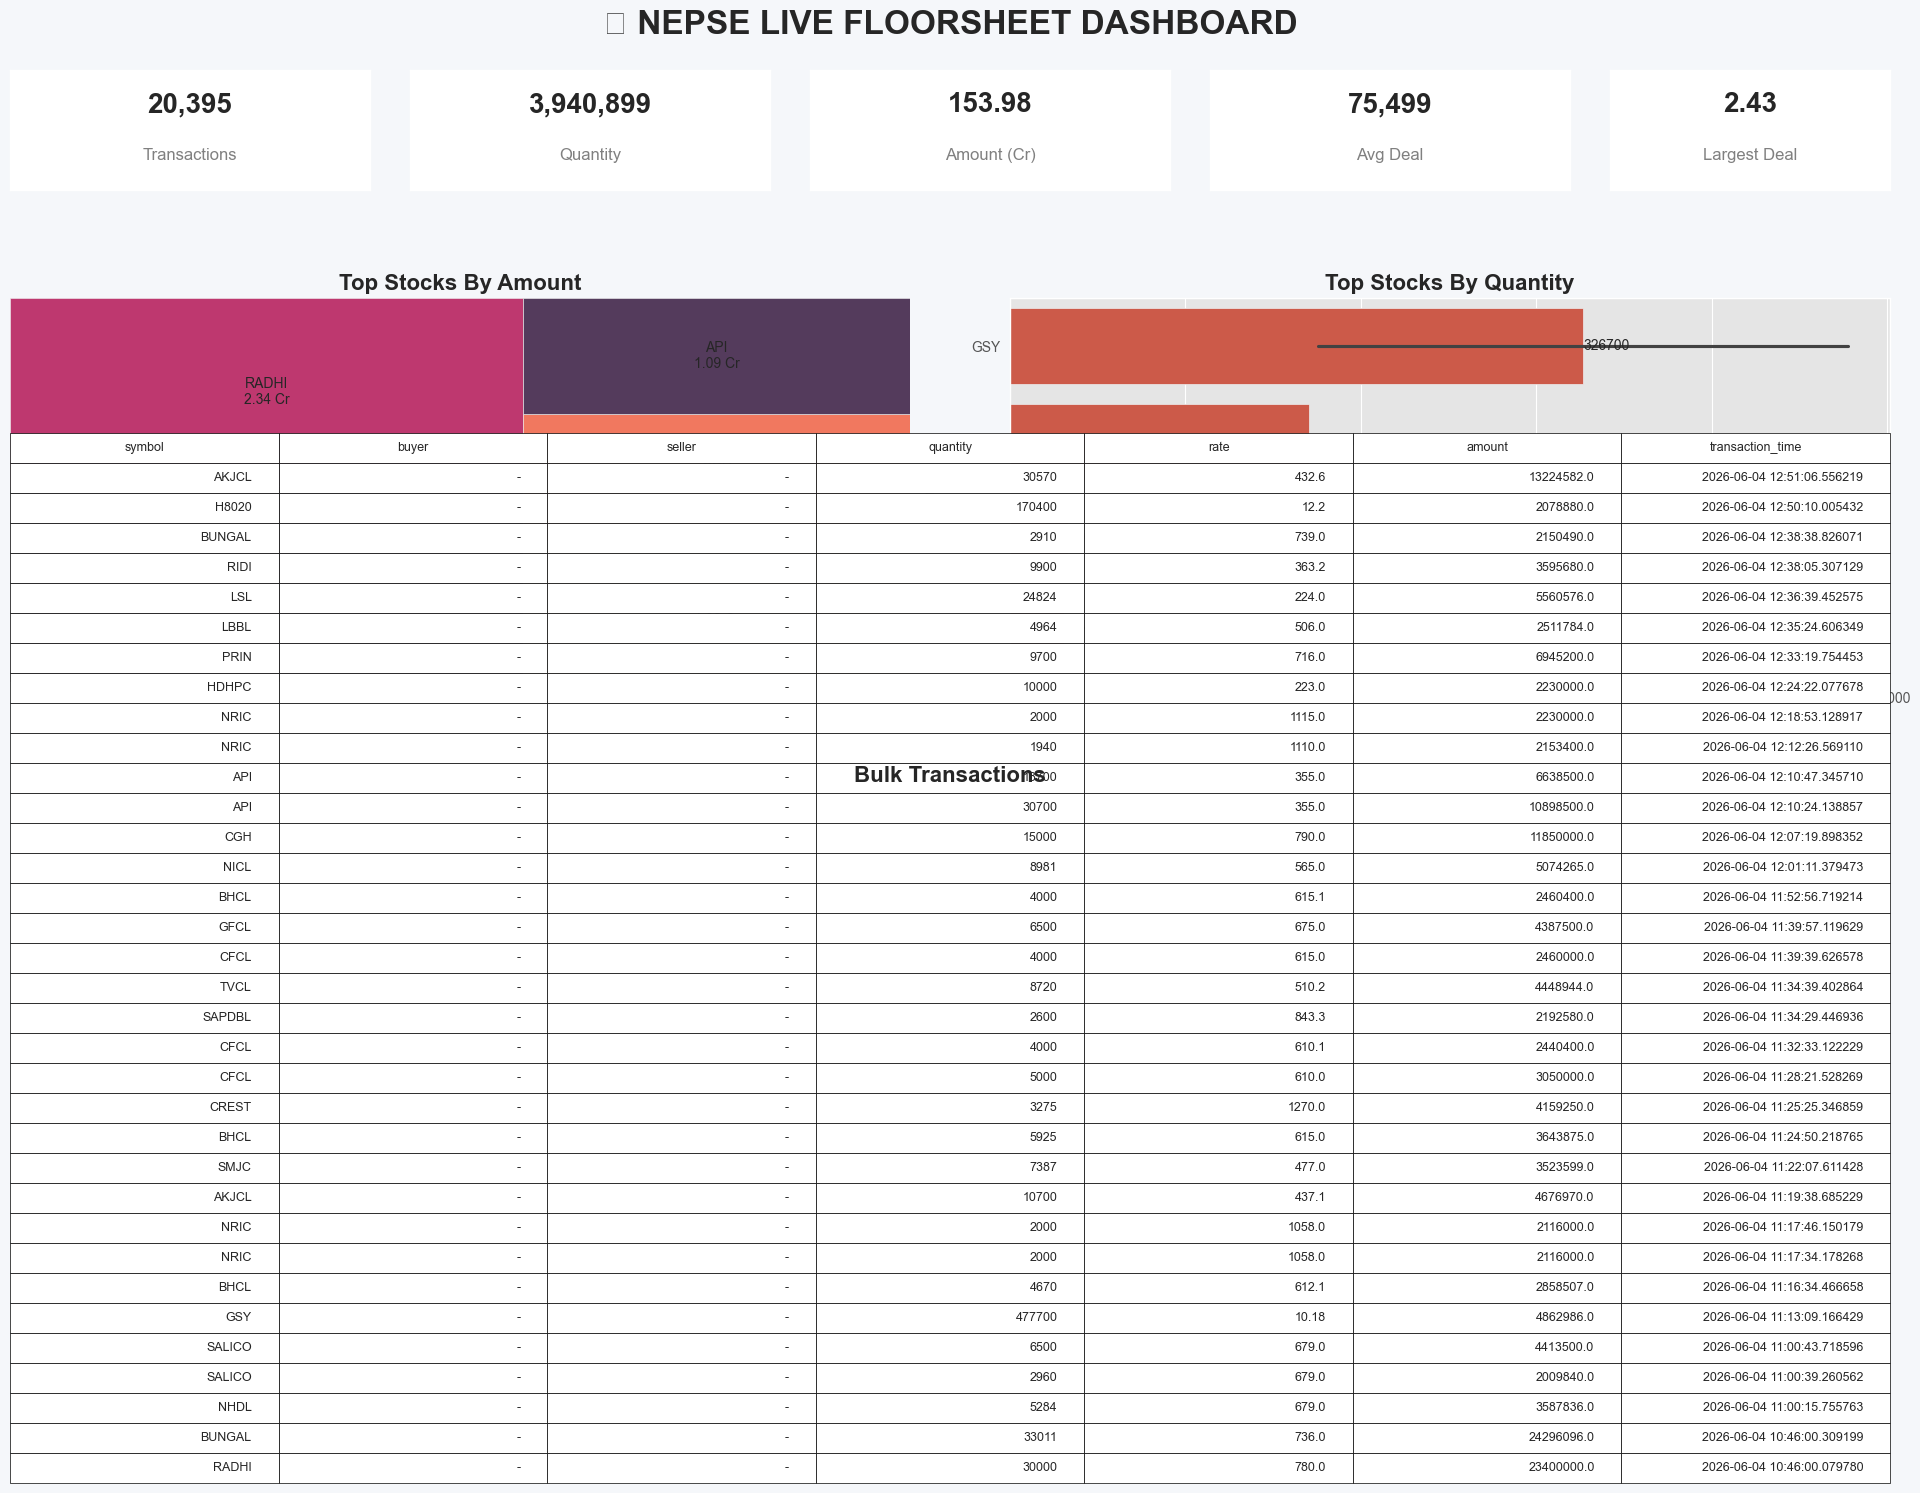

In [26]:
nepalytix_dashboard()

In [28]:
data.keys()

dict_keys(['message', 'latest_date', 'scan_time', 'filters', 'summary', 'largest_transaction', 'top_5_by_amount', 'top_5_by_quantity', 'transactions_over_time', 'bulk_transactions'])

In [30]:
pd.DataFrame(data["top_5_by_quantity"])

,symbol,buyer,seller,quantity,rate,amount,transaction_time
0,GSY,-,-,477700,10.18,4862986.0,2026-06-04 11:13:09.166429
1,GSY,-,-,175700,10.02,1760514.0,2026-06-04 11:35:01.993017
2,BUNGAL,-,-,33011,736.00,24296096.0,2026-06-04 10:46:00.309199
3,API,-,-,30700,355.00,10898500.0,2026-06-04 12:10:24.138857
4,RADHI,-,-,30000,780.00,23400000.0,2026-06-04 10:46:00.079780


In [31]:
pd.DataFrame(data["top_5_by_amount"])

,symbol,buyer,seller,quantity,rate,amount,transaction_time
0,BUNGAL,-,-,33011,736.0,24296096.0,2026-06-04 10:46:00.309199
1,RADHI,-,-,30000,780.0,23400000.0,2026-06-04 10:46:00.079780
2,CGH,-,-,15000,790.0,11850000.0,2026-06-04 12:07:19.898352
3,API,-,-,30700,355.0,10898500.0,2026-06-04 12:10:24.138857
4,PRIN,-,-,9700,716.0,6945200.0,2026-06-04 12:33:19.754453


## Bankings sectors 

In [ ]:
https://api.nepalytix.com/api/treemap/stocks-by-sector/?sector=Banking

In [34]:
url = "https://api.nepalytix.com/api/treemap/stocks-by-sector/?sector=Banking"

headers = {
    "Authorization": "Bearer YOUR_TOKEN"
}

response = requests.get(url,headers=headers)

response

<Response [401]>